# Nama: Katarina Aini
# NIM: 4222311025
# Kelas: A Malam

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
print(df.shape)

df.info()

(1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## EDA

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


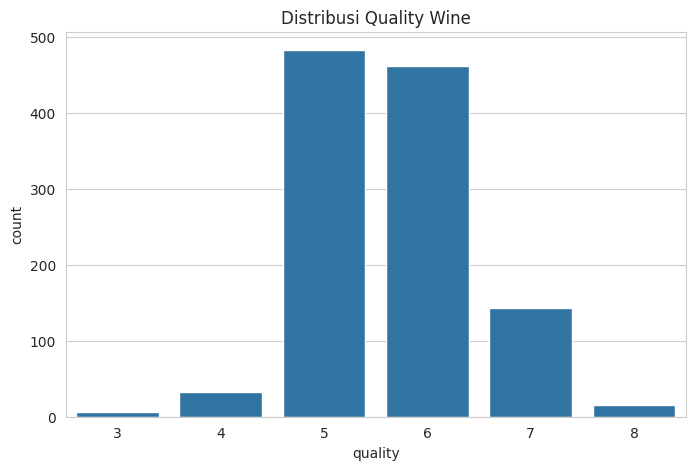

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='quality')

plt.title('Distribusi Quality Wine')
plt.show()

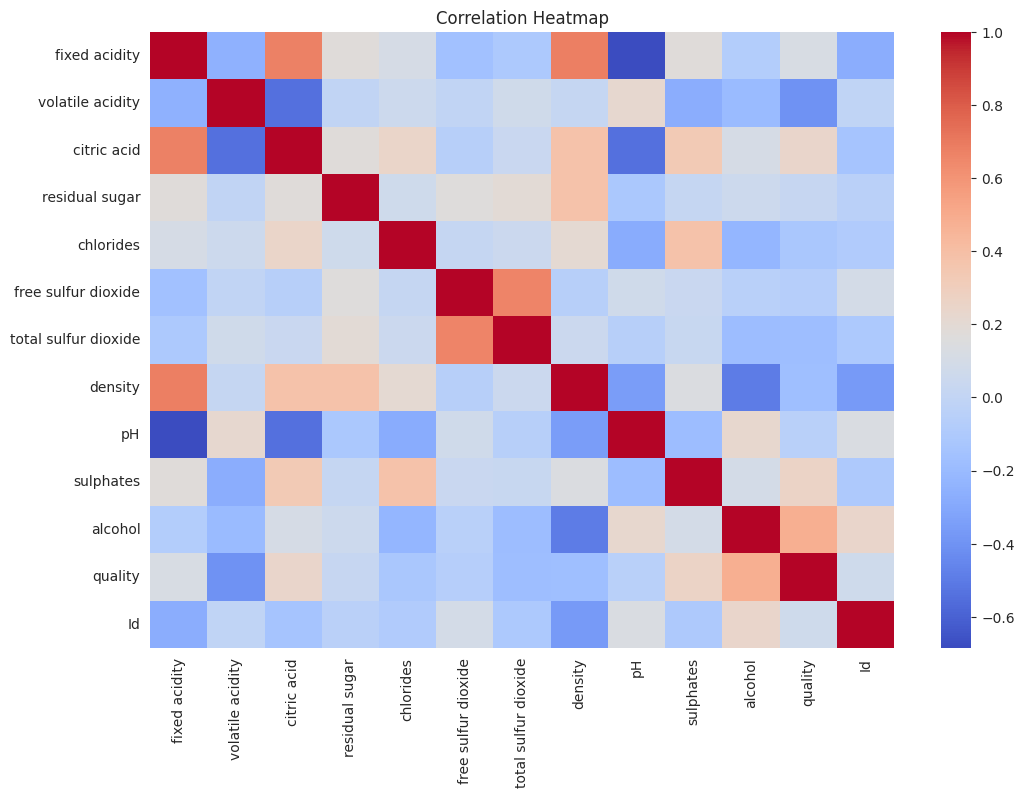

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

In [8]:
# Drop Duplicates

df = df.drop_duplicates().reset_index(drop=True)

In [9]:
df = df.drop(columns=['Id'])

In [10]:
# Feature and Label

X = df.drop(columns=['quality'])

y = df['quality']

In [11]:
# Feature Scalling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## K-means Clustering

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)

cluster = kmeans.fit_predict(X_scaled)

In [13]:
df['cluster'] = cluster

In [14]:
# Metode Elbow

inertia = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

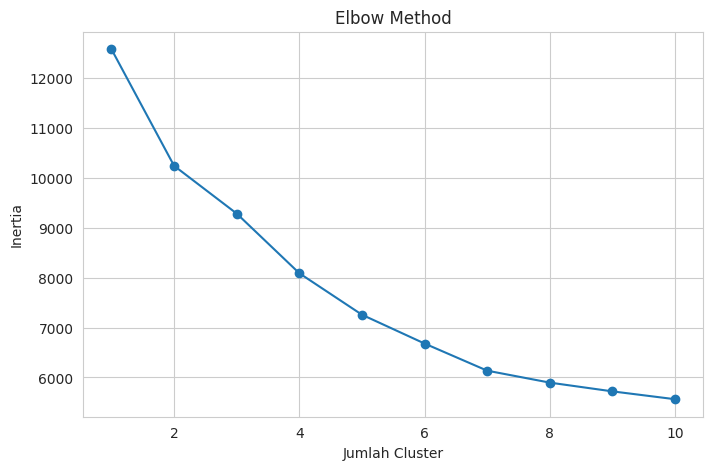

In [15]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

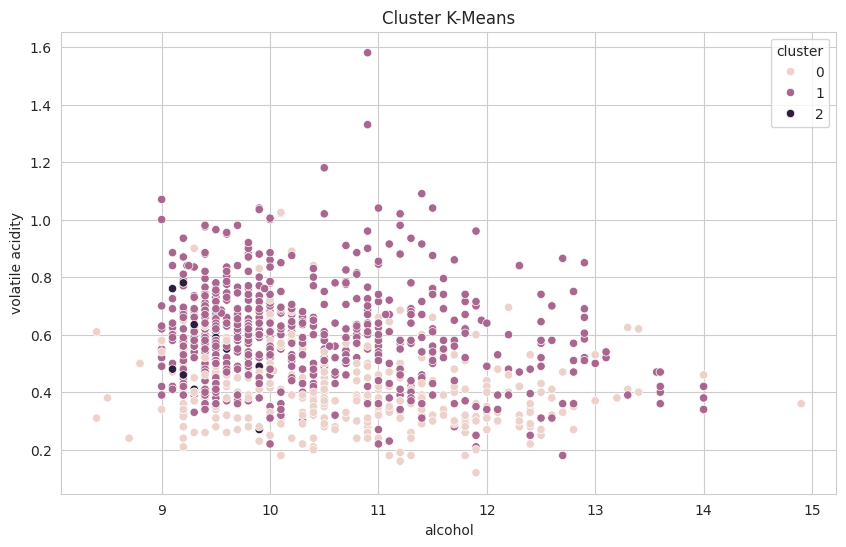

In [16]:
# Visualisasi Cluster

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['alcohol'],
    y=df['volatile acidity'],
    hue=df['cluster']
)

plt.title('Cluster K-Means')
plt.show()

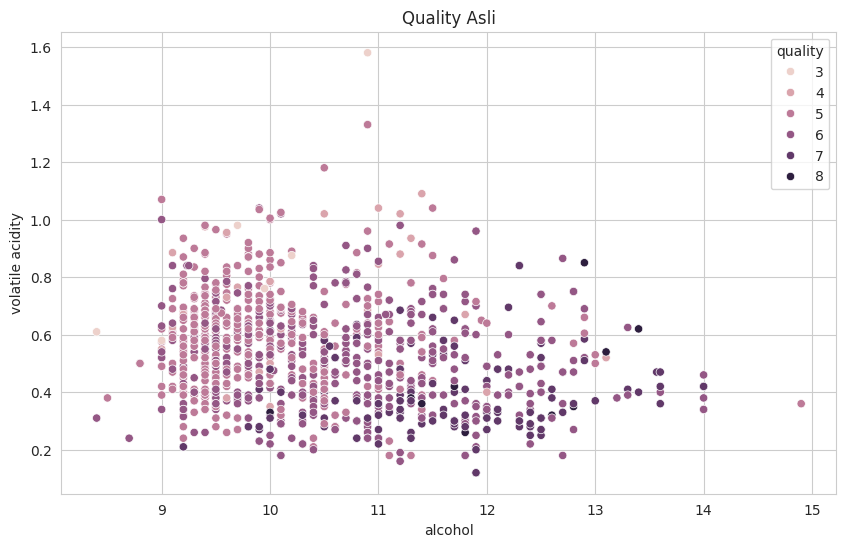

In [17]:
# Visualisasi Quality

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['alcohol'],
    y=df['volatile acidity'],
    hue=df['quality']
)

plt.title('Quality Asli')
plt.show()

### Via Score Plot

In [18]:
sil_score = silhouette_score(X_scaled, cluster)

print(sil_score)

0.21811891686992646


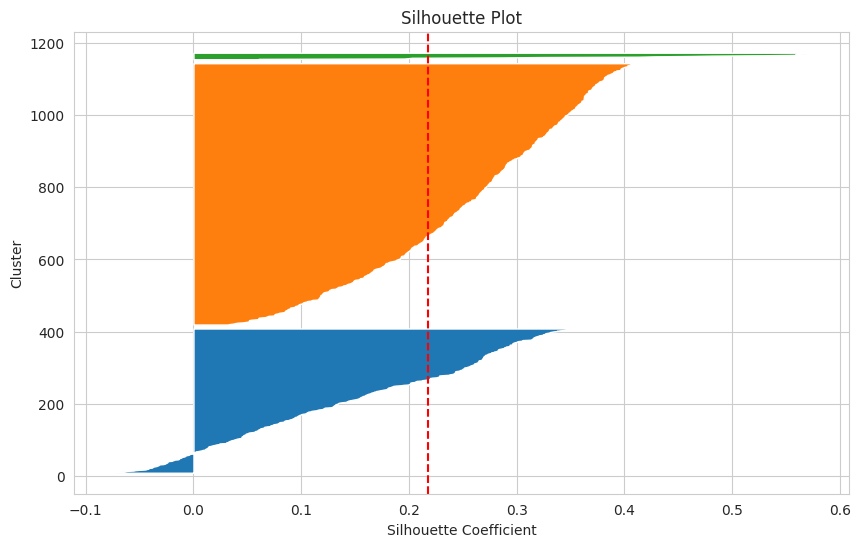

In [19]:
# Evaluasi Pada K-Means Menggunakan Via Score Secara Visualisasi

from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_scaled, cluster)

y_lower = 10

plt.figure(figsize=(10,6))

for i in range(3):

    cluster_silhouette_vals = silhouette_vals[cluster == i]
    cluster_silhouette_vals.sort()

    y_upper = y_lower + len(cluster_silhouette_vals)

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals
    )

    y_lower = y_upper + 10

plt.axvline(sil_score, color='red', linestyle='--')

plt.title('Silhouette Plot')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')

plt.show()

## Kesimpulan Analisis Wine Dataset

Dari analisis dataset 'WineQT.csv' yang dilakukan, beberapa poin penting dapat disimpulkan:

1.  **Eksplorasi Data Awal (EDA)**:
    *   Dataset terdiri dari 1143 sampel dengan 13 fitur, termasuk 'quality' sebagai target dan 'Id' yang kemudian dihapus.
    *   Tidak ada nilai null yang ditemukan dalam dataset, menunjukkan kualitas data yang baik untuk analisis.
    *   Distribusi kualitas wine menunjukkan bahwa sebagian besar wine memiliki kualitas 5 dan 6.
    *   Heatmap korelasi menunjukkan hubungan antar fitur, misalnya, 'alcohol' memiliki korelasi positif dengan 'quality', sedangkan 'volatile acidity' memiliki korelasi negatif yang cukup kuat dengan 'quality'.

2.  **Feature Engineering & Scaling**:
    *   Duplikat baris dihapus untuk memastikan keunikan data.
    *   Kolom 'Id' dihilangkan karena tidak relevan untuk pemodelan.
    *   Fitur-fitur (X) dipisahkan dari target ('quality', y) dan kemudian diskalakan menggunakan `StandardScaler` untuk menstandarisasi rentang nilai, yang penting untuk algoritma berbasis jarak seperti K-Means.

3.  **K-Means Clustering**:
    *   Awalnya, model K-Means diinisialisasi dengan 3 kluster. Metode Elbow digunakan untuk membantu menentukan jumlah kluster optimal, meskipun tidak ada 'siku' yang sangat jelas dari plot.
    *   Visualisasi kluster K-Means dibandingkan dengan kualitas asli menunjukkan adanya perbedaan dalam pengelompokan. Misalnya, 'alcohol' dan 'volatile acidity' adalah fitur-fitur yang cukup berperan dalam pembentukan kluster.
    *   Perhitungan Silhouette Score memberikan nilai sekitar 0.218, yang mengindikasikan bahwa kluster-kluster yang terbentuk memiliki sedikit tumpang tindih dan tidak terlalu padat. Visualisasi Silhouette Plot memberikan gambaran lebih lanjut tentang seberapa baik setiap sampel diklasifikasikan ke dalam klusternya.

Secara keseluruhan, analisis ini memberikan gambaran tentang karakteristik wine dan bagaimana K-Means dapat digunakan untuk mengelompokkan wine berdasarkan properti fisika-kimia, meskipun dengan Silhouette Score yang relatif rendah, menunjukkan bahwa mungkin ada tumpang tindih antar kluster atau fitur-fitur yang digunakan kurang cukup untuk pemisahan yang sangat jelas.

### Thank you :)